In [51]:

import pandas as pd
print("ok")

ok


In [52]:

!pip install pandas


'pip' n'est pas reconnu en tant que commande interne
ou externe, un programme ex�cutable ou un fichier de commandes.


In [53]:

import pandas as pd
print("ok")


ok


In [54]:

import pandas as pd
import matplotlib.pyplot as plt
import sklearn

print("tout marche")

tout marche


In [55]:
!pip install matplotlib

'pip' n'est pas reconnu en tant que commande interne
ou externe, un programme ex�cutable ou un fichier de commandes.


In [56]:

import pandas as pd
import matplotlib.pyplot as plt
import sklearn

print("tout marche")

tout marche


In [57]:
!pip install pandas matplotlib scikit-learn plotly folium

'pip' n'est pas reconnu en tant que commande interne
ou externe, un programme ex�cutable ou un fichier de commandes.


In [58]:

import pandas as pd
import matplotlib.pyplot as plt
import sklearn

print("tout marche")

tout marche


In [59]:
# Étape 1 : Chargement des données
import pandas as pd

data = pd.read_csv("export_IA.csv", sep=";", encoding="latin-1")

# On affiche les 5 premières lignes
print("Aperçu des données :")
print(data.head())

Aperçu des données :
            contact_operateur     nom_enseigne id_station_itinerance  \
0  bornes@solveo-energies.com  SOLVEO ENERGIES         DKMONE3785709   
1  bornes@solveo-energies.com  SOLVEO ENERGIES         DKMONE4353337   
2         contact@car2plug.fr   MAIRIE - 77640        FRC2N815458236   
3   exploitation@r3-charge.fr               R3        FR3R3P89333944   
4   exploitation@r3-charge.fr               R3        FR3R3P89333944   

                            nom_station          implantation_station  \
0                            Montestruc                Parking public   
1                               Tommy's  Parking privé à usage public   
2                        MAIRIE - 77640                        Voirie   
3  R3 - Joué-les-Tours - Pizza Del Arte  Parking privé à usage public   
4  R3 - Joué-les-Tours - Pizza Del Arte  Parking privé à usage public   

                          adresse_station  \
0    Rue du 19 mars 1962 32390 Montestruc   
1   258 Avenue la

In [60]:

# On définit la variable cible y et on veut prédire le type d’implantation de la station
y = data["implantation_station"]

# X contient toutes les autres variables ce sont les données utilisées pour faire la prédiction
X = data[[
    "nbre_pdc",   # nombre de points de charge
    "puissance_nominale",  # puissance de la borne
    "prise_type_2",  # type de prise
    "prise_type_combo_ccs",
    "prise_type_chademo",
    "paiement_acte",  # paiement possible sur place
    "condition_acces",   # accès libre ou restreint
    "reservation",  # possibilité de réserver
    "accessibilite_pmr",  # accessibilité handicap
    "restriction_gabarit",  # restrictions physiques
    "horaires"   # horaires d’accès
]]


# Vérification
print("Variables X :")
print(X.head())

print("\nVariable cible y :")
print(y.head())

Variables X :
   nbre_pdc  puissance_nominale prise_type_2 prise_type_combo_ccs  \
0         8              150.00         FAUX                 VRAI   
1         4              150.00         FAUX                 VRAI   
2         2               22.08         VRAI                 FAUX   
3         5              150.00         FAUX                 VRAI   
4         5              150.00         FAUX                 VRAI   

  prise_type_chademo paiement_acte condition_acces reservation  \
0               FAUX          VRAI     Accès libre        FAUX   
1               FAUX          VRAI     Accès libre        FAUX   
2               FAUX          VRAI     Accès libre        FAUX   
3               FAUX          VRAI     Accès libre        FAUX   
4               FAUX          VRAI     Accès libre        FAUX   

                 accessibilite_pmr restriction_gabarit horaires  
0                   Non accessible    Sans restriction     24/7  
1  Accessible mais non réservé PMR    Sans

In [61]:
#Nettoyage des données / Vérification des valeurs manquantes
print(X.isnull().sum())

cols_bool = [
    "prise_type_2",
    "prise_type_combo_ccs",
    "prise_type_chademo",
    "paiement_acte",
    "reservation"
]

# Remplacement des valeurs manquantes dans ces colonnes
for col in cols_bool:
    if col in X.columns:
        X[col] = X[col].fillna("FAUX")

# Pour les autres colonnes → remplacer par "inconnu"
X = X.fillna("inconnu")

# Vérification après nettoyage
print("\nValeurs manquantes APRÈS nettoyage :")
print(X.isnull().sum())

nbre_pdc                 0
puissance_nominale       0
prise_type_2            69
prise_type_combo_ccs    69
prise_type_chademo      69
paiement_acte           69
condition_acces          0
reservation             69
accessibilite_pmr        0
restriction_gabarit      0
horaires                 0
dtype: int64

Valeurs manquantes APRÈS nettoyage :
nbre_pdc                0
puissance_nominale      0
prise_type_2            0
prise_type_combo_ccs    0
prise_type_chademo      0
paiement_acte           0
condition_acces         0
reservation             0
accessibilite_pmr       0
restriction_gabarit     0
horaires                0
dtype: int64


In [62]:

# Conversion des valeurs booléennes texte → nombres
X = X.replace({
    "VRAI": 1,
    "FAUX": 0,
    "True": 1,
    "False": 0,
    "TRUE": 1,
    "FALSE": 0
})

print("Conversion VRAI/FAUX faite")

Conversion VRAI/FAUX faite


In [63]:

# Encodage des variables catégorielles (texte à numérique)

from sklearn.preprocessing import LabelEncoder

encoders = {}

for col in X.columns:
    #  on encode TOUT ce qui n’est pas numérique
    if X[col].dtype != 'int64' and X[col].dtype != 'float64':
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
        encoders[col] = le

# Encodage de y
le_y = LabelEncoder()
y = le_y.fit_transform(y.astype(str))

print(" Encodage terminé")

 Encodage terminé


In [64]:
#Nouvelle verification

print("\nTypes des colonnes :")
print(X.dtypes)

print("\nColonnes encore en texte :")
print(X.select_dtypes(include=['object']).columns)

print("\nAperçu des données :")
print(X.head())


Types des colonnes :
nbre_pdc                  int64
puissance_nominale      float64
prise_type_2              int64
prise_type_combo_ccs      int64
prise_type_chademo        int64
paiement_acte             int64
condition_acces           int64
reservation               int64
accessibilite_pmr         int64
restriction_gabarit       int64
horaires                  int64
dtype: object

Colonnes encore en texte :
Index([], dtype='str')

Aperçu des données :
   nbre_pdc  puissance_nominale  prise_type_2  prise_type_combo_ccs  \
0         8              150.00             0                     1   
1         4              150.00             0                     1   
2         2               22.08             1                     0   
3         5              150.00             0                     1   
4         5              150.00             0                     1   

   prise_type_chademo  paiement_acte  condition_acces  reservation  \
0                   0              1      

In [65]:
#Train / Test

# Séparation des données
from sklearn.model_selection import train_test_split

# 80% pour entraîner / 20% pour tester
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Affichage des tailles
print("Taille X_train :", X_train.shape)
print("Taille X_test :", X_test.shape)

Taille X_train : (3826, 11)
Taille X_test : (957, 11)


In [66]:
#Modèle
# Initialisation du modèle Random Forest
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

#Vérification
print("Modèle créé :", model)

Modèle créé : RandomForestClassifier()


In [67]:
#GridSearch
# On optimise les paramètres du modèle
from sklearn.model_selection import GridSearchCV

# Paramètres à tester
param_grid = {
    'n_estimators': [50, 100,150],         # nombre d’arbres
    'max_depth': [10, 20,None],            # profondeur
    'min_samples_split': [2, 5,10]         # conditions de division
}

# Création du GridSearch
grid = GridSearchCV(model, param_grid, cv=2, n_jobs=-1)

# Entraînement du modèle + test des combinaisons
print("Entraînement en cours...")
grid.fit(X_train, y_train)

# Meilleur modèle trouvé
best_model = grid.best_estimator_

# Affichage des paramètres optimaux
print("\nMeilleurs paramètres :")
print(grid.best_params_)

Entraînement en cours...


c:\Users\PC\anaconda3\envs\projet_ia\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=2.
  warnings.warn(



Meilleurs paramètres :
{'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 50}


In [68]:
#Evaluation
# On teste le modèle sur les données de test
from sklearn.metrics import accuracy_score, classification_report

# Prédictions
y_pred = best_model.predict(X_test)

# Accuracy = taux de bonnes prédictions
print("Accuracy :", accuracy_score(y_test, y_pred))

# Détail des performances
print("\nRapport de classification :")
print(classification_report(y_test, y_pred))

Accuracy : 0.9780564263322884

Rapport de classification :
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.98      0.98      0.98       272
           2       1.00      0.96      0.98       192
           3       0.98      0.96      0.97       119
           4       0.97      0.99      0.98       374

    accuracy                           0.98       957
   macro avg       0.79      0.78      0.78       957
weighted avg       0.98      0.98      0.98       957



c:\Users\PC\anaconda3\envs\projet_ia\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\PC\anaconda3\envs\projet_ia\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\PC\anaconda3\envs\projet_ia\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


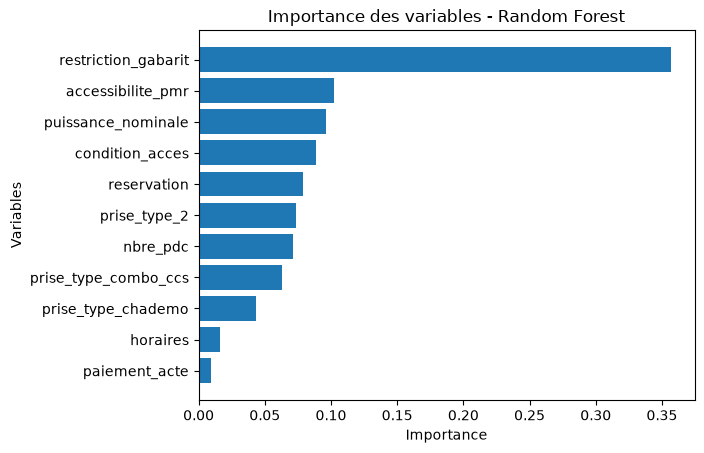

In [69]:
# Importance des variances du modèle Random Forest

import matplotlib.pyplot as plt
import pandas as pd

# Récupérer l'importance des variables
importances = best_model.feature_importances_

# Associer avec les noms des colonnes
feature_names = X.columns

# Créer un DataFrame
feat_imp = pd.DataFrame({
    "Variable": feature_names,
    "Importance": importances
})

# Trier du plus important au moins important
feat_imp = feat_imp.sort_values(by="Importance", ascending=False)

# Affichage
plt.figure()

plt.barh(feat_imp["Variable"], feat_imp["Importance"])

plt.title("Importance des variables - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Variables")

plt.gca().invert_yaxis()  # met les plus importantes en haut

plt.show()

In [70]:

# Modèle SVM

from sklearn.svm import SVC

# Initialisation du modèle SVM
svm_model = SVC()
print("Modèle SVM créé")

#Entraînement du modèle SVM
print("Entraînement du SVM...")
svm_model.fit(X_train, y_train)

#Prédictions SVM
y_pred_svm = svm_model.predict(X_test)
print("Prédiction SVM terminée")

Modèle SVM créé
Entraînement du SVM...
Prédiction SVM terminée


In [71]:

#Evaluation SVM

from sklearn.metrics import accuracy_score, classification_report

# Accuracy
print("Accuracy SVM :", accuracy_score(y_test, y_pred_svm))

# Rapport de classification
print("\nRapport de classification SVM :")
print(classification_report(y_test, y_pred_svm))

Accuracy SVM : 0.7335423197492164

Rapport de classification SVM :
              precision    recall  f1-score   support

           1       0.79      0.74      0.76       272
           2       0.76      0.73      0.74       192
           3       0.81      0.43      0.56       119
           4       0.68      0.83      0.75       374

    accuracy                           0.73       957
   macro avg       0.76      0.68      0.70       957
weighted avg       0.74      0.73      0.73       957



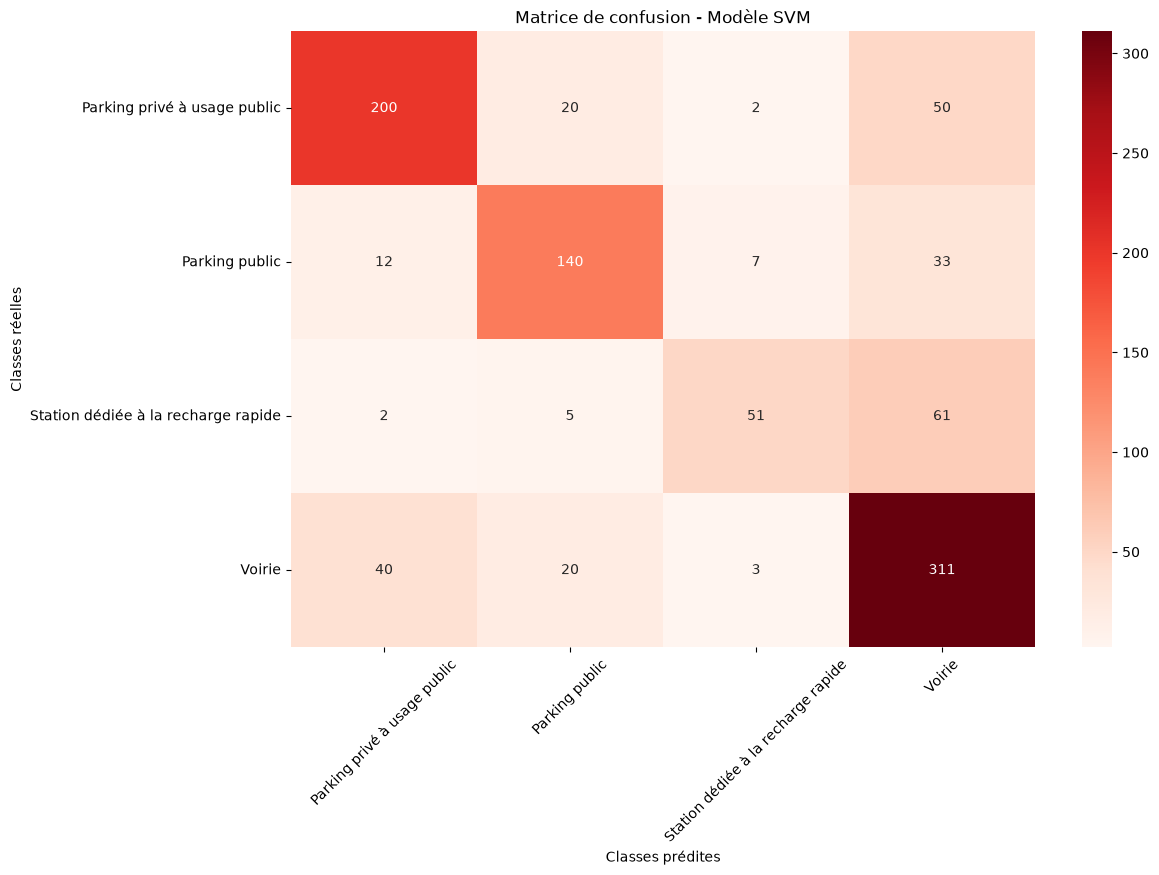

In [72]:
#Matrice de confusion SVM 

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Matrice de confusion
cm_svm = confusion_matrix(y_test, y_pred_svm)

# Labels réels
labels = np.unique(y_test)
labels_names = le_y.inverse_transform(labels)

# Création figure
plt.figure(figsize=(12,8))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt='d',
    cmap='Reds',
    xticklabels=labels_names,
    yticklabels=labels_names
)

# Titres et labels
plt.title("Matrice de confusion - Modèle SVM")
plt.xlabel("Classes prédites")
plt.ylabel("Classes réelles")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()

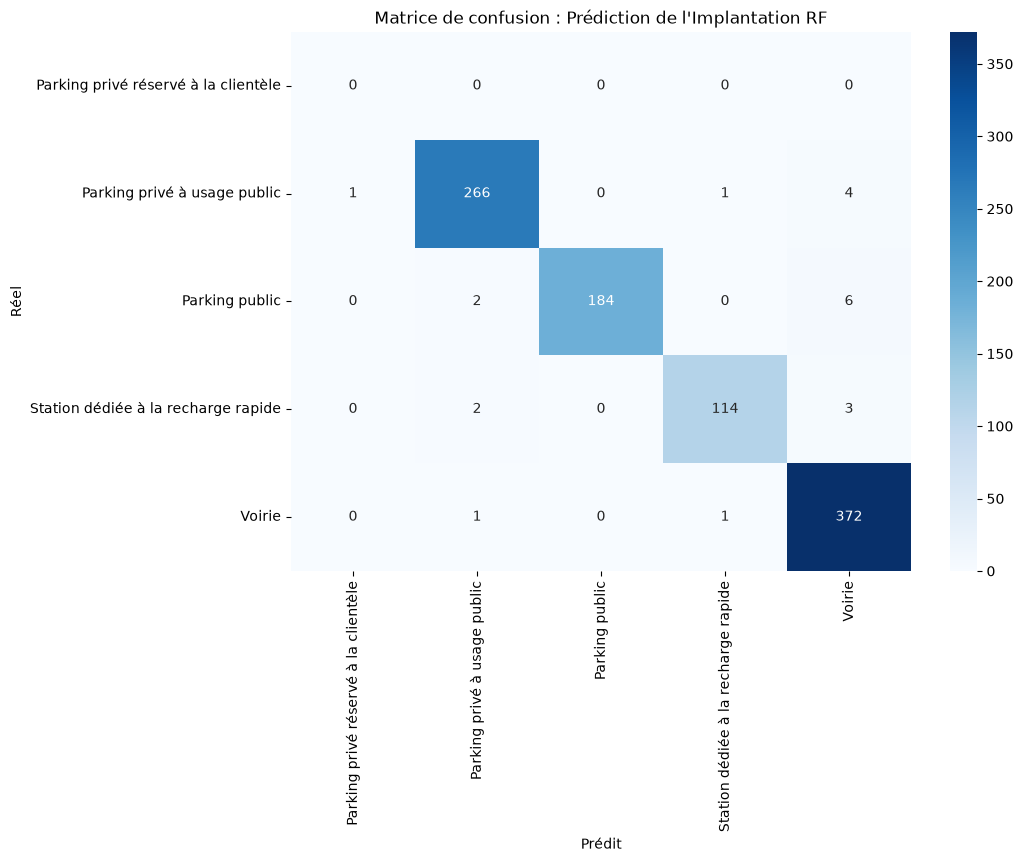

In [73]:

# Import des bibliothèques nécessaires
from sklearn.metrics import confusion_matrix
import seaborn as sns   # pour une belle visualisation
import matplotlib.pyplot as plt

# Calcul de la matrice de confusion
# Compare les vraies valeurs (y_test) et les prédictions (y_pred)
cm = confusion_matrix(y_test, y_pred)

# Création de la figure 
plt.figure(figsize=(10,7))

# Affichage de la matrice sous forme de heatmap (carte de chaleur)
sns.heatmap(
    cm,
    annot=True,                  # affiche les valeurs dans les cases
    fmt='d',                    # format entier
    xticklabels=le_y.classes_,  # noms des classes prédites
    yticklabels=le_y.classes_,  # noms des classes réelles
    cmap='Blues'                # couleur (bleu)
)

# Titre du graphique 
plt.title('Matrice de confusion : Prédiction de l\'Implantation RF')

# Nom des axes
plt.ylabel('Réel')     # vraies classes
plt.xlabel('Prédit')   # classes prédites

# Sauvegarde de l’image pour ton rapport 
plt.savefig('matrice_confusion_implantation_RF.png')

# Affichage du graphique
plt.show()

In [74]:
#Comparaison entre SVM et Random Forest

# Comparaison des modèles
print("Comparaison des modèles :\n")

# Random Forest
rf_acc = accuracy_score(y_test, y_pred)
print("Random Forest Accuracy :", rf_acc)

# SVM
svm_acc = accuracy_score(y_test, y_pred_svm)
print("SVM Accuracy :", svm_acc)

# Comparaison finale
print("\n Conclusion :")
if rf_acc > svm_acc:
    print("Random Forest est le meilleur modèle")
elif svm_acc > rf_acc:
    print("SVM est le meilleur modèle")
else:
    print("Les deux modèles ont des performances similaires")

Comparaison des modèles :

Random Forest Accuracy : 0.9780564263322884
SVM Accuracy : 0.7335423197492164

 Conclusion :
Random Forest est le meilleur modèle


In [75]:
#Sauvegarde

import joblib

# Sauvegarde Random Forest
joblib.dump(best_model, "modele_random_forest.pkl")

# Sauvegarde SVM
joblib.dump(svm_model, "modele_svm.pkl")


# Sauvegarde des encodeurs des variables X
joblib.dump(encoders, "encoders.pkl")

# Sauvegarde de l’encodeur de y
joblib.dump(le_y, "encoder_y.pkl")

# (OPTIONNEL si on a un préprocesseur type StandardScaler / ColumnTransformer)
# joblib.dump(preprocessor, "preprocessor.pkl")


print("Modèles et prétraitements sauvegardés :")
print(" modele_random_forest.pkl")
print(" modele_svm.pkl")
print(" encoders.pkl")
print(" encoder_y.pkl")
# print(" preprocessor.pkl")

Modèles et prétraitements sauvegardés :
 modele_random_forest.pkl
 modele_svm.pkl
 encoders.pkl
 encoder_y.pkl
